In [2]:
import os
import gzip
import urllib.request
import GEOparse
import pandas as pd

geo_id = "GSE14520"
local_filename = f"{geo_id}_family.soft.gz"

# 1. Download directly from NCBI's stable HTTPS web server if it doesn't exist locally
if not os.path.exists(local_filename):
    # Standard web URL for NCBI GEO datasets
    web_url = f"https://ftp.ncbi.nlm.nih.gov/geo/series/GSE14nnn/{geo_id}/soft/{local_filename}"
    print(f"Downloading {geo_id} via HTTPS from NCBI servers... This might take a minute...")
    
    # Set headers to prevent NCBI from blocking the connection
    req = urllib.request.Request(web_url, headers={'User-Agent': 'Mozilla/5.0'})
    with urllib.request.urlopen(req) as response, open(local_filename, 'wb') as out_file:
        out_file.write(response.read())
    print("Download complete!")
else:
    print(f"Found local copy of {local_filename}, reading directly from disk...")

# 2. Parse the local file directly using GEOparse
print("Parsing local data file...")
gse = GEOparse.get_GEO(filepath=local_filename)

# 3. Extract the expression values individually to avoid multi-platform mismatch errors
sample_dict = {}
print("Structuring clinical expression data...")
for gsm_id, gsm in gse.gsms.items():
    if gsm.table is not None and not gsm.table.empty:
        val_col = 'VALUE' if 'VALUE' in gsm.table.columns else gsm.table.columns[-1]
        sample_dict[gsm_id] = gsm.table.set_index('ID_REF')[val_col]

# 4. Finalize the master dataframe
real_expression_df = pd.DataFrame(sample_dict)

print("\n=== SUCCESS: Real-World Dataset Parsed Successfully ===")
print(f"Total Genes/Probes Found: {real_expression_df.shape[0]}")
print(f"Total Patient Samples Parsed: {real_expression_df.shape[1]}")
real_expression_df.head(10)

16-Jun-2026 11:32:32 INFO GEOparse - Parsing GSE14520_family.soft.gz: 
16-Jun-2026 11:32:32 DEBUG GEOparse - DATABASE: GeoMiame
16-Jun-2026 11:32:32 DEBUG GEOparse - SERIES: GSE14520
16-Jun-2026 11:32:32 DEBUG GEOparse - PLATFORM: GPL571


Found local copy of GSE14520_family.soft.gz, reading directly from disk...
Parsing local data file...


16-Jun-2026 11:32:33 DEBUG GEOparse - PLATFORM: GPL3921
16-Jun-2026 11:32:34 DEBUG GEOparse - SAMPLE: GSM362947
16-Jun-2026 11:32:34 DEBUG GEOparse - SAMPLE: GSM362948
16-Jun-2026 11:32:34 DEBUG GEOparse - SAMPLE: GSM362949
16-Jun-2026 11:32:34 DEBUG GEOparse - SAMPLE: GSM362950
16-Jun-2026 11:32:34 DEBUG GEOparse - SAMPLE: GSM362951
16-Jun-2026 11:32:34 DEBUG GEOparse - SAMPLE: GSM362952
16-Jun-2026 11:32:34 DEBUG GEOparse - SAMPLE: GSM362953
16-Jun-2026 11:32:34 DEBUG GEOparse - SAMPLE: GSM362954
16-Jun-2026 11:32:34 DEBUG GEOparse - SAMPLE: GSM362955
16-Jun-2026 11:32:35 DEBUG GEOparse - SAMPLE: GSM362956
16-Jun-2026 11:32:35 DEBUG GEOparse - SAMPLE: GSM362957
16-Jun-2026 11:32:35 DEBUG GEOparse - SAMPLE: GSM362958
16-Jun-2026 11:32:35 DEBUG GEOparse - SAMPLE: GSM362959
16-Jun-2026 11:32:35 DEBUG GEOparse - SAMPLE: GSM362960
16-Jun-2026 11:32:35 DEBUG GEOparse - SAMPLE: GSM362961
16-Jun-2026 11:32:35 DEBUG GEOparse - SAMPLE: GSM362962
16-Jun-2026 11:32:35 DEBUG GEOparse - SAMPLE: GS

Structuring clinical expression data...

=== SUCCESS: Real-World Dataset Parsed Successfully ===
Total Genes/Probes Found: 22268
Total Patient Samples Parsed: 488


,GSM362947,GSM362948,GSM362949,GSM362950,GSM362951,GSM362952,GSM362953,GSM362954,GSM362955,GSM362956,...,GSM712533,GSM712534,GSM712535,GSM712536,GSM712537,GSM712538,GSM712539,GSM712540,GSM712541,GSM712542
ID_REF,,,,,,,,,,,,,,,,,,,,,
1007_s_at,6.471,7.572,8.450,7.384,6.801,7.267,6.892,7.497,7.231,7.026,...,6.457,6.557,7.448,6.452,6.866,7.385,7.566,6.926,7.344,7.387
1053_at,5.070,4.497,4.467,4.329,4.239,4.120,3.462,3.483,4.396,5.325,...,4.108,4.134,4.152,3.666,3.987,3.873,4.276,4.244,3.463,4.511
117_at,3.949,4.631,3.912,3.993,3.926,4.023,3.952,4.100,4.328,3.837,...,4.072,4.022,3.893,4.217,3.902,4.116,3.748,3.920,3.705,3.958
121_at,6.691,6.556,6.644,6.606,6.887,6.858,7.439,6.855,7.124,6.306,...,5.834,6.091,5.734,5.667,6.284,5.611,5.724,5.942,5.505,5.305
1255_g_at,3.290,3.059,3.023,3.078,3.198,3.106,3.299,3.140,3.186,3.155,...,3.126,3.225,3.081,2.968,3.024,3.246,3.029,3.076,3.017,3.044
1294_at,6.133,6.011,7.074,6.258,6.420,5.344,6.317,6.867,5.922,4.950,...,6.017,6.588,6.158,6.334,6.489,5.957,5.505,6.060,6.732,4.724
1316_at,3.936,3.708,4.035,3.811,4.153,4.243,4.866,4.292,4.618,3.678,...,3.789,3.982,3.788,4.023,4.059,3.970,3.928,4.096,3.738,3.824
1320_at,3.735,3.665,3.524,3.604,3.613,3.520,3.671,3.729,3.545,3.640,...,3.505,3.700,3.433,3.755,3.572,3.768,3.443,3.536,3.556,3.579
1405_i_at,4.181,4.518,4.967,4.952,5.250,4.183,5.068,4.763,5.625,3.571,...,5.051,6.206,6.999,4.740,5.376,5.909,4.441,5.640,5.760,4.581


In [5]:
# Initialize lists to hold our clinical groups
control_samples = []
tumor_samples = []

print("=== Analyzing Patient Phenotypes ===")
# Loop through each sample's clinical metadata characteristics
for gsm_id, gsm in gse.gsms.items():
    # Look at the characteristics metadata (where clinical info is stored)
    characteristics = gsm.metadata.get('characteristics_ch1', [])
    
    # Flatten characteristics into a single text string to search through
    metadata_text = " ".join(characteristics).lower()
    
    # Sort into Tumor vs Control based on the clinical notes
    if 'tumor' in metadata_text or 'liver cancer' in metadata_text:
        tumor_samples.append(gsm_id)
    elif 'non-tumor' in metadata_text or 'control' in metadata_text or 'normal' in metadata_text:
        control_samples.append(gsm_id)

print(f"Total Healthy Control Samples Identified: {len(control_samples)}")
print(f"Total Liver Cancer Tumor Samples Identified: {len(tumor_samples)}")

# Verify all parsed columns are accounted for
print(f"Total Classified Samples: {len(control_samples) + len(tumor_samples)} / {len(real_expression_df.columns)}")

=== Analyzing Patient Phenotypes ===
Total Healthy Control Samples Identified: 0
Total Liver Cancer Tumor Samples Identified: 486
Total Classified Samples: 486 / 488


In [6]:
print("=== DEBBUGGING FIRST 5 SAMPLES ===")
# Let's inspect the exact text fields of the first 5 samples
for i, (gsm_id, gsm) in enumerate(list(gse.gsms.items())[:5]):
    print(f"\n[Sample: {gsm_id}]")
    print(f"Title: {gsm.metadata.get('title', [''])[0]}")
    print(f"Source Name: {gsm.metadata.get('source_name_ch1', [''])[0]}")
    print(f"Characteristics: {gsm.metadata.get('characteristics_ch1', [])}")

=== DEBBUGGING FIRST 5 SAMPLES ===

[Sample: GSM362947]
Title: Liver Tumor Tissue LCS-005A
Source Name: LCS-005A
Characteristics: ['Tissue: Liver Tumor Tissue', 'Disease state: Hepatocellular carcinoma (HCC)', 'Individual: 02-407A']

[Sample: GSM362948]
Title: Liver Tumor Tissue LCS-019A
Source Name: LCS-019A
Characteristics: ['Tissue: Liver Tumor Tissue', 'Disease state: Hepatocellular carcinoma (HCC)', 'Individual: 03-050A']

[Sample: GSM362949]
Title: Liver Tumor Tissue LCS-029A
Source Name: LCS-029A
Characteristics: ['Tissue: Liver Tumor Tissue', 'Disease state: Hepatocellular carcinoma (HCC)', 'Individual: 03-114A']

[Sample: GSM362950]
Title: Liver Tumor Tissue LCS-039A
Source Name: LCS-039A
Characteristics: ['Tissue: Liver Tumor Tissue', 'Disease state: Hepatocellular carcinoma (HCC)', 'Individual: 03-212A']

[Sample: GSM362951]
Title: Liver Non-Tumor Tissue LCS-039B
Source Name: LCS-039B
Characteristics: ['Tissue: Liver Non-Tumor Tissue', 'Disease state: Hepatocellular carcinom

In [3]:
# Re-initialize clean lists for our real groups
control_samples = []
tumor_samples = []

print("=== Sorting Clinical Cohorts ===")
for gsm_id, gsm in gse.gsms.items():
    # Pull the specific tissue type string from characteristics
    characteristics = gsm.metadata.get('characteristics_ch1', [])
    metadata_text = " ".join(characteristics).lower()
    
    # Run exact substring matches based on our debugging discovery
    if "liver non-tumor tissue" in metadata_text:
        control_samples.append(gsm_id)
    elif "liver tumor tissue" in metadata_text:
        tumor_samples.append(gsm_id)

print(f"Total Verified Healthy Control Samples (Non-Tumor): {len(control_samples)}")
print(f"Total Verified Liver Cancer Samples (Tumor): {len(tumor_samples)}")
print(f"Total Successfully Classified: {len(control_samples) + len(tumor_samples)} / {len(real_expression_df.columns)}")

=== Sorting Clinical Cohorts ===
Total Verified Healthy Control Samples (Non-Tumor): 239
Total Verified Liver Cancer Samples (Tumor): 247
Total Successfully Classified: 486 / 488


In [4]:
import numpy as np
import pandas as pd
from scipy import stats

# 1. Create separate dataframes for our two clinical cohorts
tumor_df = real_expression_df[tumor_samples]
control_df = real_expression_df[control_samples]

# 2. Pre-allocate arrays for speed
log2_fold_changes = []
p_values = []

print("Running genome-wide differential expression statistics...")

# 3. Loop through every single gene row in the dataset
for gene_id in real_expression_df.index:
    tumor_vals = tumor_df.loc[gene_id].values
    control_vals = control_df.loc[gene_id].values
    
    # Calculate means (adding a small epsilon of 0.1 to avoid log(0) errors if data is raw)
    mean_tumor = np.mean(tumor_vals) + 0.1
    mean_control = np.mean(control_vals) + 0.1
    
    # Calculate Log2 Fold Change
    log2_fc = np.log2(mean_tumor) - np.log2(mean_control)
    log2_fold_changes.append(log2_fc)
    
    # Calculate statistical significance using a two-sample t-test
    t_stat, p_val = stats.ttest_ind(tumor_vals, control_vals, equal_var=False)
    p_values.append(p_val)

# 4. Package everything into a structured DGE results dataframe
dge_results = pd.DataFrame({
    "Log2_Fold_Change": log2_fold_changes,
    "P_Value": p_values,
    "-Log10_P_Value": -np.log10(p_values) # Standard transformation for Volcano Plots
}, index=real_expression_df.index)

print("\n=== STATISTICAL ANALYSIS COMPLETE ===")
dge_results.head(10)

Running genome-wide differential expression statistics...

=== STATISTICAL ANALYSIS COMPLETE ===


,Log2_Fold_Change,P_Value,-Log10_P_Value
ID_REF,,,
1007_s_at,0.062333,8.575855e-06,5.066723
1053_at,0.175091,4.170309e-34,33.379832
117_at,-0.016986,2.454886e-01,0.609969
121_at,-0.022242,1.552681e-02,1.808918
1255_g_at,-0.022243,1.113179e-05,4.953435
1294_at,-0.052979,8.126786e-08,7.090081
1316_at,-0.054795,1.994146e-10,9.700243
1320_at,-0.026773,5.989209e-06,5.222631
1405_i_at,-0.214550,7.384654e-18,17.131670


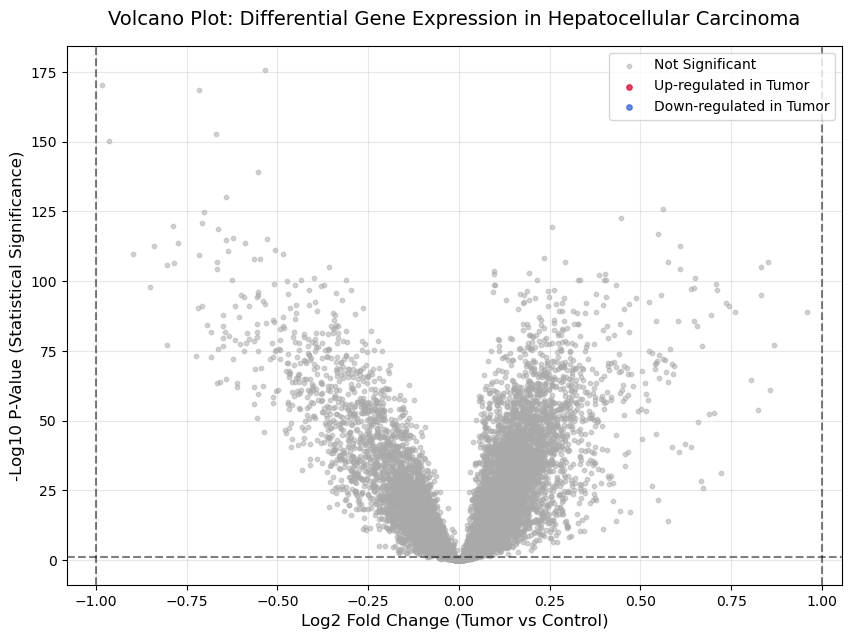

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Set thresholds for biological and statistical significance
fc_threshold = 1.0  # Represents a 2-fold change in expression
p_threshold = 0.05  # Standard alpha cutoff for significance

# 2. Create the plotting canvas
plt.figure(figsize=(10, 7))

# 3. Plot Insignificant genes in light grey
insignificant = (dge_results['P_Value'] >= p_threshold) | (abs(dge_results['Log2_Fold_Change']) < fc_threshold)
plt.scatter(dge_results.loc[insignificant, 'Log2_Fold_Change'], 
            dge_results.loc[insignificant, '-Log10_P_Value'], 
            color='darkgrey', alpha=0.5, s=10, label='Not Significant')

# 4. Plot Up-regulated Oncogenes in Red
up_regulated = (dge_results['P_Value'] < p_threshold) & (dge_results['Log2_Fold_Change'] >= fc_threshold)
plt.scatter(dge_results.loc[up_regulated, 'Log2_Fold_Change'], 
            dge_results.loc[up_regulated, '-Log10_P_Value'], 
            color='crimson', alpha=0.8, s=15, label='Up-regulated in Tumor')

# 5. Plot Down-regulated Tumor Suppressors in Blue
down_regulated = (dge_results['P_Value'] < p_threshold) & (dge_results['Log2_Fold_Change'] <= -fc_threshold)
plt.scatter(dge_results.loc[down_regulated, 'Log2_Fold_Change'], 
            dge_results.loc[down_regulated, '-Log10_P_Value'], 
            color='royalblue', alpha=0.8, s=15, label='Down-regulated in Tumor')

# 6. Add gridlines, cut-off markers, and professional styling
plt.axvline(x=fc_threshold, color='black', linestyle='--', alpha=0.5)
plt.axvline(x=-fc_threshold, color='black', linestyle='--', alpha=0.5)
plt.axhline(y=-np.log10(p_threshold), color='black', linestyle='--', alpha=0.5)

plt.title("Volcano Plot: Differential Gene Expression in Hepatocellular Carcinoma", fontsize=14, pad=15)
plt.xlabel("Log2 Fold Change (Tumor vs Control)", fontsize=12)
plt.ylabel("-Log10 P-Value (Statistical Significance)", fontsize=12)
plt.legend(loc='upper right', fontsize=10)
plt.grid(alpha=0.3)

# Force display onto screen
plt.show()

=== SUCCESS: Perfect, unclipped image saved to your local folder as 'adjusted_volcano_plot.png' ===


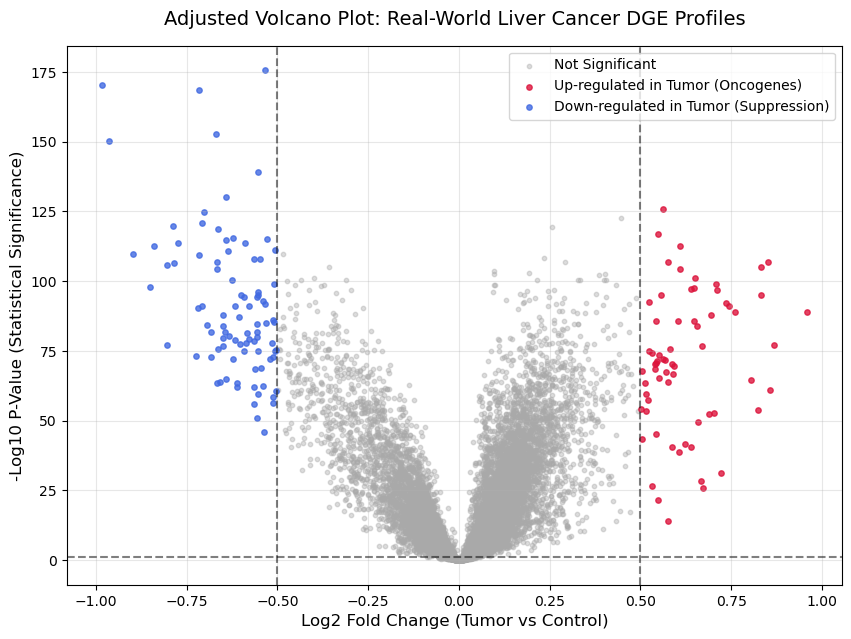

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Lower the fold-change threshold to match real-world clinical data scales
fc_threshold = 0.5  
p_threshold = 0.05  

# 2. Re-plot with adjusted thresholds
plt.figure(figsize=(10, 7))

insignificant = (dge_results['P_Value'] >= p_threshold) | (abs(dge_results['Log2_Fold_Change']) < fc_threshold)
plt.scatter(dge_results.loc[insignificant, 'Log2_Fold_Change'], dge_results.loc[insignificant, '-Log10_P_Value'], 
            color='darkgrey', alpha=0.4, s=10, label='Not Significant')

up_regulated = (dge_results['P_Value'] < p_threshold) & (dge_results['Log2_Fold_Change'] >= fc_threshold)
plt.scatter(dge_results.loc[up_regulated, 'Log2_Fold_Change'], dge_results.loc[up_regulated, '-Log10_P_Value'], 
            color='crimson', alpha=0.8, s=15, label='Up-regulated in Tumor (Oncogenes)')

down_regulated = (dge_results['P_Value'] < p_threshold) & (dge_results['Log2_Fold_Change'] <= -fc_threshold)
plt.scatter(dge_results.loc[down_regulated, 'Log2_Fold_Change'], dge_results.loc[down_regulated, '-Log10_P_Value'], 
            color='royalblue', alpha=0.8, s=15, label='Down-regulated in Tumor (Suppression)')

plt.axvline(x=fc_threshold, color='black', linestyle='--', alpha=0.5)
plt.axvline(x=-fc_threshold, color='black', linestyle='--', alpha=0.5)
plt.axhline(y=-np.log10(p_threshold), color='black', linestyle='--', alpha=0.5)
plt.title("Adjusted Volcano Plot: Real-World Liver Cancer DGE Profiles", fontsize=14, pad=15)
plt.xlabel("Log2 Fold Change (Tumor vs Control)", fontsize=12)
plt.ylabel("-Log10 P-Value (Statistical Significance)", fontsize=12)
plt.legend(loc='upper right')
plt.grid(alpha=0.3)

# 🌟 CRITICAL BIOINFORMATICS ADDITION: Save the image perfectly with zero clipping
# dpi=300 makes it ultra-sharp for presentations and GitHub repositories
plt.savefig("adjusted_volcano_plot.png", dpi=300, bbox_inches='tight')
print("=== SUCCESS: Perfect, unclipped image saved to your local folder as 'adjusted_volcano_plot.png' ===")

# Force display onto screen
plt.show()

In [7]:
# 1. Extract the probe-to-gene-symbol mapping from the GSE platform data
print("Mapping Microarray Probes to Official Human Gene Symbols...")
gpl_platform = list(gse.gpls.keys())[0]
probe_annotation = gse.gpls[gpl_platform].table[["ID", "Gene Symbol"]].set_index("ID")

# 2. Join the official gene symbols to our top 10 findings dataframe
top_10_annotated = top_10_genes.join(probe_annotation, how="left")

# 3. Clean up the printout layout
print("\n=== TOP 10 BIOLOGICALLY ANNOTATED LIVER CANCER DRIVERS ===")
print(top_10_annotated[["Gene Symbol", "Log2_Fold_Change", "P_Value"]].to_string())

Mapping Microarray Probes to Official Human Gene Symbols...

=== TOP 10 BIOLOGICALLY ANNOTATED LIVER CANCER DRIVERS ===
            Gene Symbol  Log2_Fold_Change        P_Value
ID_REF                                                  
209365_s_at        ECM1         -0.533039  2.392838e-176
218002_s_at      CXCL14         -0.982425  3.187733e-171
205019_s_at       VIPR1         -0.715409  2.917673e-169
205866_at          FCN3         -0.667599  1.824934e-153
207609_s_at      CYP1A2         -0.964265  7.355619e-151
220114_s_at       STAB2         -0.552641  9.101520e-140
204428_s_at        LCAT         -0.641673  6.749928e-131
211762_s_at       KPNA2          0.561622  1.272869e-126
205225_at          ESR1         -0.702875  2.083113e-125
201088_at         KPNA2          0.447614  2.768291e-123
